# Фильтрация и группировка

Отбираем заёмщиков с кредитом меньше 10 000 руб., затем на таблице продаж стройматериалов (табл. 3.9 методички) делаем три группировки: по дате, клиенту и товару

Отобранные заемщики с кредитом < 10000 руб:
    Сумма кредита  Стоимость кредита  Срок кредита Дата кредитования  \
1            4500                900             6          20.12.02   
5            7500               1500            18          22.12.02   
9            9000               1800            18          27.12.02   
12           6500               1300             6          28.12.02   
17           4000                800            18          03.01.03   

                    Цель кредитования  Количество  Возраст  Пол  Образование  \
1                                Иное           1       44  Жен       высшее   
5       Покупка и ремонт недвижимости           1       66  Жен  специальное   
9                      Покупка товара           1       56  Жен       высшее   
12  Оплата услуг (мед., юрид. и т.п.)           1       38  Жен       высшее   
17                     Покупка товара           1       60  Жен  специальное   

   Частная собственность  Срок работы по с

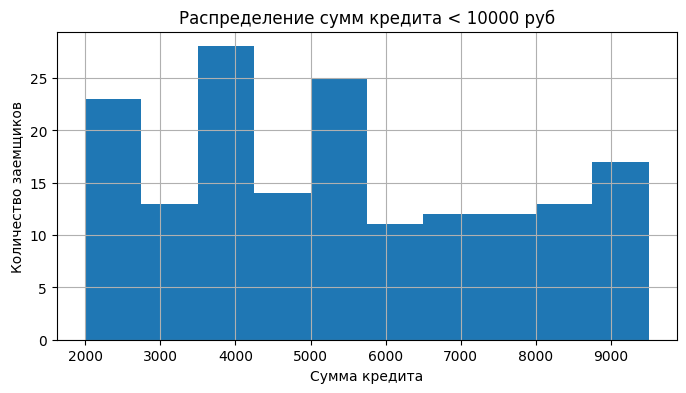

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#Загрузка данных
df = pd.read_csv('data/Credit.txt', sep='\t', encoding='cp1251')

#Фильтрация: кредит < 10000
filtered = df[df["Сумма кредита"] < 10000]

#Вывод первых строк результата
print("Отобранные заемщики с кредитом < 10000 руб:")
print(filtered.head())

#Статистика
print("\nСтатистические показатели:")
print(filtered.describe(include="all"))

#Визуализация распределения сумм кредита
plt.figure(figsize=(8,4))
plt.title("Распределение сумм кредита < 10000 руб")
filtered["Сумма кредита"].hist()
plt.xlabel("Сумма кредита")
plt.ylabel("Количество заемщиков")
plt.show()

In [2]:
#Таблица 3.9
data = {
    "Дата": [
        "01.03.2024","01.03.2024","01.03.2024",
        "02.03.2024","02.03.2024","02.03.2024",
        "03.03.2024","03.03.2024","03.03.2024","03.03.2024",
        "04.03.2024","04.03.2024","04.03.2024","04.03.2024",
        "05.03.2024","05.03.2024","05.03.2024","05.03.2024",
        "06.03.2024","06.03.2024","06.03.2024"
    ],
    "Клиент": [
        "ООО «Полигон»","ЗАО «Монтажник»","ООО «Тандем»",
        "ООО «Шплинт»","ЗАО «Монтажник»","ООО «Полигон»",
        "ООО «Агрострой»","ЗАО «Монтажник»","ООО «Тандем»","ООО «Полигон»",
        "ООО «Шплинт»","ООО «Тандем»","ЗАО «Монтажник»","ООО «Полигон»",
        "ООО «Агрострой»","ООО «Шплинт»","ЗАО «Монтажник»","ООО «Тандем»",
        "ООО «Полигон»","ООО «Агрострой»","ЗАО «Монтажник»"
    ],
    "Товар": [
        "Цемент","Керамзит","Кирпич",
        "Плиты","Блоки","Кирпич",
        "Плиты","Керамзит","Блоки","Плиты",
        "Керамзит","Кирпич","Цемент","Блоки",
        "Плиты","Керамзит","Цемент","Блоки",
        "Кирпич","Керамзит","Цемент"
    ],
    "Цена": [
        150,100,1500,
        1100,900,1500,
        1100,100,900,1100,
        100,1500,150,900,
        1100,100,150,900,
        1500,100,150
    ],
    "Количество": [
        20,60,5,
        10,20,10,
        8,30,10,30,
        100,10,20,15,
        20,50,40,15,
        6,70,30
    ],
    "Сумма": [
        3000,6000,7500,
        11000,18000,15000,
        8800,3000,9000,33000,
        10000,15000,3000,13500,
        22000,5000,6000,13500,
        9000,7000,4500
    ]
}

df = pd.DataFrame(data)
df.head()


,Дата,Клиент,Товар,Цена,Количество,Сумма
0,01.03.2024,ООО «Полигон»,Цемент,150,20,3000
1,01.03.2024,ЗАО «Монтажник»,Керамзит,100,60,6000
2,01.03.2024,ООО «Тандем»,Кирпич,1500,5,7500
3,02.03.2024,ООО «Шплинт»,Плиты,1100,10,11000
4,02.03.2024,ЗАО «Монтажник»,Блоки,900,20,18000


In [3]:
group_by_date = df.groupby("Дата").agg({
    "Цена": "mean",          #средняя цена
    "Количество": "sum",      #суммарное количество
    "Сумма": "sum"            #суммарная выручка
}).reset_index()

print("Группировка по дате:")
print(group_by_date)


Группировка по дате:
         Дата         Цена  Количество  Сумма
0  01.03.2024   583.333333          85  16500
1  02.03.2024  1166.666667          40  44000
2  03.03.2024   800.000000          78  53800
3  04.03.2024   662.500000         145  41500
4  05.03.2024   562.500000         125  46500
5  06.03.2024   583.333333         106  20500


In [4]:
group_by_client = df.groupby("Клиент").agg({
    "Цена": "mean",
    "Количество": "sum",
    "Сумма": "sum"
}).reset_index()

print("Группировка по клиенту:")
print(group_by_client)


Группировка по клиенту:
            Клиент         Цена  Количество  Сумма
0  ЗАО «Монтажник»   258.333333         200  40500
1  ООО «Агрострой»   766.666667          98  37800
2    ООО «Полигон»  1030.000000          81  73500
3     ООО «Тандем»  1200.000000          40  45000
4     ООО «Шплинт»   433.333333         160  26000


In [5]:
group_by_product = df.groupby("Товар").agg({
    "Цена": "mean",
    "Количество": "sum",
    "Сумма": "sum"
}).reset_index()

print("Группировка по товару:")
print(group_by_product)


Группировка по товару:
      Товар    Цена  Количество  Сумма
0     Блоки   900.0          60  54000
1  Керамзит   100.0         310  31000
2    Кирпич  1500.0          31  46500
3     Плиты  1100.0          68  74800
4    Цемент   150.0         110  16500
